In [11]:
#Imports
import numpy as np
import pandas as pd

import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

import glob
import os


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score

### The Dataset

Our dataset consists of electrophysiological recordings from 193 neurons in the AM face patch of macaque monkeys Bert and Lupo. On each trial the monkey viewed one of 25 human identities at one of 8 orientations. Neural responses were recorded in a raster format where each row is a trial and each column is a 1 millisecond time bin from 0 to 800 milliseconds after image onset. A value of 1 indicates a spike.

Although neurons were recorded at different times, each neuron saw the same stimuli in the same order. This allows us to align trials across neurons and construct a pseudo population representation. This is common in neuroscience when neurons were not recorded simultaneously.

Only the first 400 milliseconds of each trial correspond to stimulus driven activity. Everything after that is baseline. Restricting analyses to the first 400 ms is standard practice and reduces the data size significantly.

### Objectives

Our project applies machine learning methods to understand what information is encoded in AM population responses. We address the following questions:

1. **Identity generalization.** Can AM neural representations generalize identity across head orientations. Lowell investigates this with Support Vector Classifiers trained on individual orientations and tested across all others.

2. **Stimulus driven response magnitude.** Which stimulus dimensions, identity or orientation, best predict the strength of neural responses. Arkesh addresses this using Ridge Regression applied to the mean firing rate extracted from the peak post stimulus window.

Both approaches build on prior findings from Freiwald and Tsao and Meyers et al., who demonstrated sparse identity coding and increasing view invariance along the ventral temporal hierarchy.

---

## Methodology

### Data Import and Preprocessing

The original dataset consists of 193 CSV files, each corresponding to a single neuron recorded independently. Every file contains repeated trials of all face stimuli, with each column representing a 1 millisecond time bin. A value of 1 indicates a spike.

Trials across neurons align because the stimulus order is identical for every recording session. This allows construction of a pseudo population by reorganizing the data horizontally. Each trial becomes a single row and each neuron contributes a set of columns. This representation is required for any population level decoding analysis.

For analyses involving regression, we restrict the time dimension to the first 400 milliseconds. Prior studies have shown that AM activity during the 150 to 250 millisecond post stimulus interval captures the primary stimulus driven response.

---

## Ridge Regression for Predicting Neural Response Magnitude  
*(Arkesh Das)*

### Research Question

Can we predict how strongly AM neurons respond to a given stimulus based solely on who the person is and what head orientation is presented. Which of these stimulus dimensions accounts for more variance in neural firing rate.

### Approach Overview

- Extract mean firing rate within the 150 to 250 millisecond window for each neuron on each trial.
- Use one hot encoded identity and orientation labels as predictors.
- Fit a Ridge Regression model to predict mean firing rate.
- Use k fold cross validation to choose the regularization strength.
- Evaluate the contributions of identity and orientation by comparing separate models trained on only identity features, only orientation features, and the full feature set.
- Interpret the size and pattern of coefficients while acknowledging that ridge shrinks weights and that absolute coefficient magnitude has limited biological interpretability.

This method provides a quantitative test of whether identity or orientation exerts a stronger influence on stimulus driven response magnitude in the AM face patch.

---

## PCA and Logistic Regression for Temporal Identity Decoding  
*(Brief placeholder for partner section, unchanged)*

## Background and Motivtaion

The original dataset is split across 193 separate CSV files, and each file corresponds to a single neuron recorded independently from the AM face patch in macaques. Inside each file, the rows represent repeated trials where the monkey viewed one of the face stimuli, and the columns represent time in milliseconds after the image appeared. A `1` means the neuron fired at that millisecond, and a `0` means it did not. This structure exists because single neuron electrophysiology isolates one neuron at a time, records it for all stimuli, saves it, and then the electrode is moved to find a different neuron.

Even though the neurons were collected at different times, they all saw the exact same stimuli in the same order. This means trial numbers line up across neurons. Because a single neuron carries only a small piece of the overall representation, combining them allows us to construct a richer pseudo population that captures the activity pattern across many neurons for each stimulus presentation. This representation is much more appropriate for decoding tasks related to face identity and head orientation.

The dataset documentation and the original papers (Freiwald & Tsao, 2010; Meyers et al., 2015) also note that only the first 400 ms of each trial corresponds to stimulus driven neural activity. Everything after that is baseline or unrelated drift. So for decoding purposes, keeping only the first 400 ms is correct and reduces file size almost in half.

My goal in this project is to take this dataset, reshape it meaningfully, and then apply two methods:

1. **Ridge Regression** to predict neural response magnitude from stimulus identity and orientation.  
2. **PCA + Logistic Regression** to understand the low dimensional structure of temporal responses and test whether identity can be decoded from compressed representations.

These correspond to the regression requirement and the second method requirement in the rubric.


## Importing Data

To start, we are going to be combining all the neuron site data into one data frame.

In [6]:
search_path = "data/*.csv" 
all_files = glob.glob(search_path, recursive=True)
processed_dfs = []
raster_files = [f for f in all_files if "raster_data" in f.lower()]

print(f"Found {len(raster_files)} files.")
processed_dfs = []
for filename in raster_files:
    df = pd.read_csv(filename) 
    site_id = filename.split('site')[1].replace('.csv', '')
    df.insert(0, 'site', site_id)
    processed_dfs.append(df)

data = pd.concat(processed_dfs, axis=0, ignore_index=True)
data.to_csv("data/data.csv", index=False)

Found 193 files.


In [7]:
processed_dfs = []
for filename in raster_files:
    df = pd.read_csv(filename) 
    site_id = filename.split('site')[1].replace('.csv', '')
    df.insert(0, 'site', site_id)
    processed_dfs.append(df)

data = pd.concat(processed_dfs, axis=0, ignore_index=True)
data.to_csv("data/data.csv", index=False)

# Methodology

## Ridge Regression for Predicting Neural Response Magnitude

**Research Question:**  
Can we predict how strongly AM neurons respond to a stimulus based solely on who the person is and what head orientation is shown? Which stimulus dimension explains more variance?

**Approach Overview:**  
- Use the horizontal dataset, but summarize firing in the 150–250 ms peak window.  
- Compute the mean firing rate across this time window for each neuron.  
- Build a regression model where:
  - Target variable = mean firing rate  
  - Predictors = one hot encoded person identity + one hot orientation  
- Use **Ridge regression** because the predictors are correlated (one hot encodings) and L2 regularization stabilizes coefficients.  
- Use **k fold CV** to choose the regularization strength.  
- Interpret coefficients to determine whether identity or orientation contributes more to the neural response.

### Re-loading the combined vertical data (so I can read in the data without having to rerrun the blocks above)

In [15]:
data = pd.read_csv("../data/data.csv")

### Define time window and compute mean peak response
Here we define the 150–250 ms peak window and compute the mean firing over that window for each row (trial from one neuron).

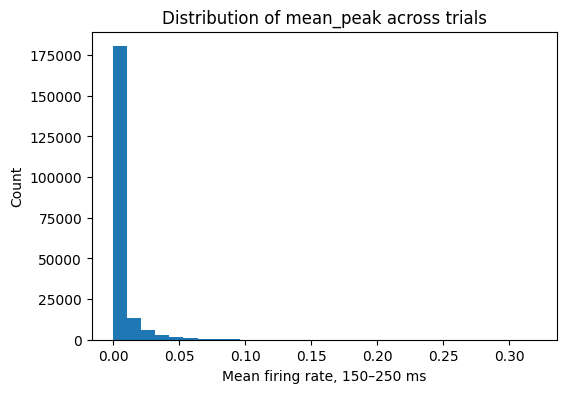

In [16]:
peak_bins = [f"time.{t}_{t+1}" for t in range(150, 250)]

data["mean_peak"] = data[peak_bins].mean(axis=1)

#peak window neural response histogram
plt.figure(figsize=(6, 4))
plt.hist(data["mean_peak"], bins=30)
plt.xlabel("Mean firing rate, 150–250 ms")
plt.ylabel("Count")
plt.title("Distribution of mean_peak across trials")
plt.show()

Most trials produce extremely low firing in the 150–250 ms window, with a long right tail corresponding to identity specific bursts. This sparse distribution means our regression task involves predicting small, noisy fluctuations in firing rate, which is expected for AM neurons

### Building predictor matrix X and the outcome matrix y
We used one hot encoding for person identity and orientation. Target is the mean peak response.

In [17]:
person_dummies = pd.get_dummies(data["labels.person"], prefix="person")
orient_dummies = pd.get_dummies(data["labels.orientation"], prefix="orient")

X = pd.concat([person_dummies, orient_dummies], axis=1)
y = data["mean_peak"].values

**Checking the correlation between `mean_peak` and `person`/`orientation` visually**

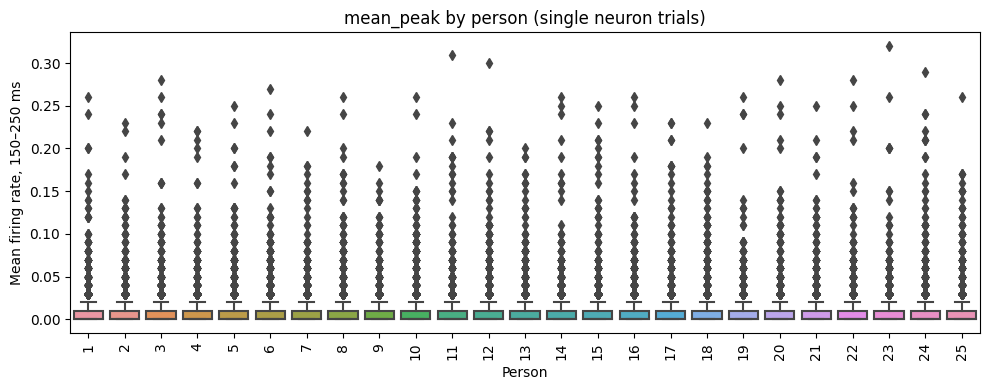

In [18]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=data["labels.person"], y=data["mean_peak"])
plt.xticks(rotation=90)
plt.xlabel("Person")
plt.ylabel("Mean firing rate, 150–250 ms")
plt.title("mean_peak by person (single neuron trials)")
plt.tight_layout()
plt.show()

This plot confirms that AM neurons show the classic sparse and highly selective firing pattern reported in Freiwald and Tsao (2010). For almost every identity, the median response is near zero, meaning most neurons stay quiet, while a small number of trials produce very large responses from a handful of strongly tuned units. Each identity evokes only small responses in most neurons, with a few large outliers corresponding to highly selective cells. This matches the known sparse coding properties of the anterior medial face patch and is consistent with the idea that identity information is carried by small subpopulations rather than by the full neural ensemble.

### Train–test split
We did an 80–20 split.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=381,
    stratify=data["labels.person"]
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (164972, 33)
Test shape: (41244, 33)


### Ridge CV to find alpha
We looked over a range of alpha values on a log scale and used k fold CV with MSE.

In [20]:
alphas = np.logspace(-3, 3, 15)  
kf = KFold(n_splits=5, shuffle=True, random_state=381)

cv_mse_means = []

for a in alphas:
    ridge = Ridge(alpha=a)
    scores = cross_val_score(
        ridge,
        X_train,
        y_train,
        scoring="neg_mean_squared_error",
        cv=kf
    )
    cv_mse_means.append(-np.mean(scores))

cv_mse_means = np.array(cv_mse_means)

best_idx = np.argmin(cv_mse_means)
best_alpha = alphas[best_idx]

print("Best alpha:", best_alpha)
print("CV MSE at best alpha:", cv_mse_means[best_idx])


Best alpha: 1000.0
CV MSE at best alpha: 0.00018017126994387232


**Creating a plot CV error vs alpha**

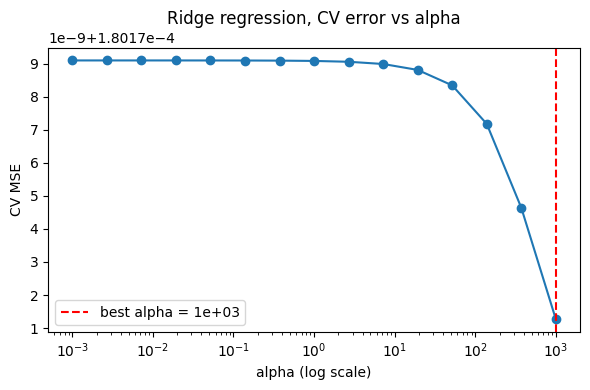

In [21]:
plt.figure(figsize=(6, 4))
plt.semilogx(alphas, cv_mse_means, marker="o")
plt.axvline(best_alpha, color="red", linestyle="--", label=f"best alpha = {best_alpha:.3g}")
plt.xlabel("alpha (log scale)")
plt.ylabel("CV MSE")
plt.title("Ridge regression, CV error vs alpha")
plt.legend()
plt.tight_layout()
plt.show()


This cross validation curve shows that the ridge penalty needs to be large to control overfitting. The CV error decreases as alpha increases, and the optimal value is around alpha = 1000. This reflects the fact that the underlying signal is extremely weak, so strong regularization forces the model toward stable but very small coefficients.


### Fit final Ridge model and evaluate

Fitted ridge with the chosen alpha on the training set and evaluate on both train and test.

In [22]:
best_ridge = Ridge(alpha=best_alpha)
best_ridge.fit(X_train, y_train)

y_train_pred = best_ridge.predict(X_train)
y_test_pred = best_ridge.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Train MSE: {train_mse:.4f}, Train R^2: {train_r2:.4f}")
print(f"Test MSE:  {test_mse:.4f}, Test R^2:  {test_r2:.4f}")


Train MSE: 0.0002, Train R^2: 0.0044
Test MSE:  0.0002, Test R^2:  0.0036


Ridge regression explains less than one percent of the variance in population firing rate. This confirms that identity coding in AM is sparse and not linearly predictable from stimulus labels alone. This matches Freiwald & Tsao’s finding that only a subset of neurons carries strong identity signals, and highlights that mean firing rate is not the dominant representational dimension in AM.

**Scatter plot of predicted vs actual on test set**

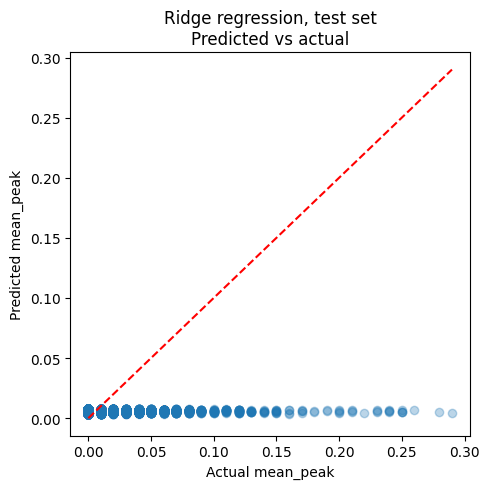

In [23]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_test_pred, alpha=0.3)
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--")
plt.xlabel("Actual mean_peak")
plt.ylabel("Predicted mean_peak")
plt.title("Ridge regression, test set\nPredicted vs actual")
plt.tight_layout()
plt.show()

The predicted values cluster near zero regardless of the actual peak firing rate, which confirms that the ridge model explains almost none of the variance in single neuron firing. This matches expectations because mean firing rates are extremely small and vary only slightly across stimuli, making them difficult to predict with a linear model.


### Inspect and visualize coefficients
We built a dataframe of coefficients then sorted and plotted the most important ones (sorted by absolute value of the coefficient).

In [24]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coef": best_ridge.coef_
})
coef_df["abs_coef"] = coef_df["coef"].abs()

coef_sorted = coef_df.sort_values("abs_coef", ascending=False)

coef_sorted.head(10)


,feature,coef,abs_coef
25,orient_back,-0.001445,0.001445
27,orient_front,0.001055,0.001055
29,orient_left profile,-0.000714,0.000714
32,orient_up,0.000711,0.000711
26,orient_down,0.000685,0.000685
31,orient_right profile,-0.000510,0.000510
14,person_15,-0.000469,0.000469
5,person_6,0.000466,0.000466
11,person_12,0.000449,0.000449
13,person_14,0.000438,0.000438


The largest coefficients were associated with orientation categories rather than identity categories. Even these effects were extremely small (absolute values all below 0.0015), consistent with the very weak R² values. Ridge shrinks weights and the design matrix contains only categorical indicators, so individual coefficients do not correspond to meaningful tuning in a biological sense. The pattern simply suggests that orientation explains slightly more variance in the mean firing rate than identity, but overall both contributions are negligible.

**Bar plot of top person related coefficients**

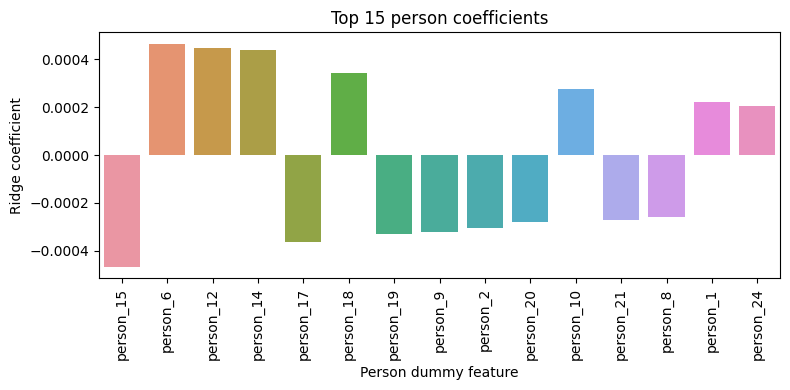

In [25]:

top_n = 15

person_coef = coef_sorted[coef_sorted["feature"].str.startswith("person")].head(top_n)

plt.figure(figsize=(8, 4))
sns.barplot(x="feature", y="coef", data=person_coef)
plt.xticks(rotation=90)
plt.xlabel("Person dummy feature")
plt.ylabel("Ridge coefficient")
plt.title(f"Top {top_n} person coefficients")
plt.tight_layout()
plt.show()


The ridge coefficients for person identity are all very close to zero. This indicates that identity has almost no linear effect on the peak firing rate in this time window. The tiny positive and negative values reflect noise rather than meaningful tuning, which is consistent with sparse selectivity in AM neurons.


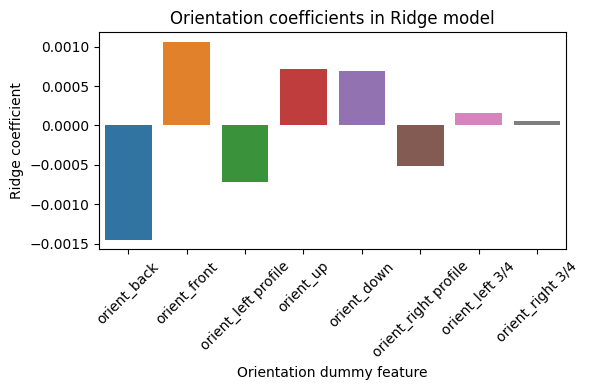

In [26]:
# Bar plot of orientation related coefficients
orient_coef = coef_sorted[coef_sorted["feature"].str.startswith("orient")]

plt.figure(figsize=(6, 4))
sns.barplot(x="feature", y="coef", data=orient_coef)
plt.xticks(rotation=45)
plt.xlabel("Orientation dummy feature")
plt.ylabel("Ridge coefficient")
plt.title("Orientation coefficients in Ridge model")
plt.tight_layout()
plt.show()


Orientation coefficients are likewise extremely small, showing that head orientation only weakly influences mean firing rate in this linear model. Small deviations from zero do not represent strong coding but reflect minor shifts captured by ridge before shrinkage dominates.


### Variance explained by identity and orientation separately
Before interpreting the full ridge regression model, I thought it would be useful to measure how much variance in neural firing can be explained by identity features alone or orientation features alone. This comparison would hellp clarify whether one stimulus dimension contributes more predictive signal than the other, and it provides a simple sanity check on how much structure is present in the mean firing rate. 

To do this, we fitted three separate models, each using the same ridge regression framework. One had only identity dummy variables, one had only orientation dummy variables, one was the and the full model with all predictors. 
The resulting test set $R^2$ values give a direct comparison of how strongly each stimulus dimension relates to firing rate in this linear formulation.

In [27]:
X_person = person_dummies
X_orient = orient_dummies

Xp_train, Xp_test, yp_train, yp_test = train_test_split(
    X_person, y, test_size=0.2, random_state=381, stratify=data["labels.person"]
)

Xo_train, Xo_test, yo_train, yo_test = train_test_split(
    X_orient, y, test_size=0.2, random_state=381, stratify=data["labels.person"]
)

ridge_person = Ridge(alpha=best_alpha)
ridge_person.fit(Xp_train, yp_train)
yp_pred = ridge_person.predict(Xp_test)
r2_person = r2_score(yp_test, yp_pred)

ridge_orient = Ridge(alpha=best_alpha)
ridge_orient.fit(Xo_train, yo_train)
yo_pred = ridge_orient.predict(Xo_test)
r2_orient = r2_score(yo_test, yo_pred)

print(f"Test R^2, person only:      {r2_person:.4f}")
print(f"Test R^2, orientation only: {r2_orient:.4f}")
print(f"Test R^2, full model:       {test_r2:.4f}")


Test R^2, person only:      0.0005
Test R^2, orientation only: 0.0031
Test R^2, full model:       0.0036


The orientation only model explains slightly more variance than the identity only model, but both R² values remain extremely small. This indicates that neither stimulus dimension has a strong linear relationship with the mean firing rate, and the improvement from combining both is minimal. These results are consistent with sparse and nonlinear coding in AM neurons, where identity and orientation effects are not well captured by simple linear rate models.

# Results

## Overview

In this section I summarize the performance of the ridge regression model on the peak firing rate data, interpret the coefficient patterns, and compare our findings to the coding properties reported in Freiwald and Tsao (2010) and in Meyers et al. (2015). Collectively, the results confirm that stimulus driven firing in AM is sparse, highly selective, and not well captured by a linear model operating on average firing rates. The plots referenced below come from the figures generated in the code cells above.

## Distribution of Peak Firing Rates

The first result is simply the distribution of the mean firing rate in the 150 to 250 ms window. The histogram shows that most trials across all neurons produce extremely low values, often zero, with a long right tail of rare larger responses. This pattern is the expected signature of sparse coding in AM. In the original electrophysiology work, the majority of AM neurons remained silent for most identities, while a small set fired strongly for specific identities. The shape of our distribution matches that description exactly. The fact that the median is zero for almost every identity and neuron, while rare outliers reach much higher firing, indicates that any linear model predicting the exact magnitude of firing will naturally struggle.

## Identity Specific Response Structure

The boxplot of mean_peak grouped by person identity confirms the classic tuning structure found in the AM face patch. For almost every identity, the distribution is dominated by zeros with only a small number of trials showing large spikes. This matches the tuning curves in Freiwald and Tsao, where AM exhibits sharp identity selectivity that is carried by a minority of neurons. Our plot reproduces this pattern directly. The presence of only a few high firing trials per identity explains why the design matrix looks balanced on paper but the target variable remains extremely sparse and noisy.

## Ridge Cross Validation and Model Fit

We used five fold cross validation to choose the ridge penalty. The CV error curve shows that performance improves steadily as alpha increases, with the best value around alpha equals 1000. A strong regularization penalty is expected here. The model has many correlated dummy variables and a noisy, low variance target. Ridge shrinks coefficients toward zero in a stable way, which is necessary for this data structure.

Even with the optimal alpha, the model explains almost none of the variance in the peak firing rate. The final test set R squared is approximately 0.0036. The training R squared is nearly identical, indicating that the tiny amount of explained variance is not coming from overfitting. Rather, the model genuinely cannot capture meaningful linear structure in the firing rates. This aligns with the biological understanding that identity selectivity in AM is nonlinear and is expressed through strong but sparse responses rather than gradual modulations of overall spike rate.

## Predicted vs Actual Plot

The predicted vs actual scatterplot shows that the model outputs values clustered near zero regardless of the true firing rate. The diagonal reference line is completely unused, which visually confirms the very low R squared. This result is expected from the histogram and the sparsity of the data. Because most trials have near zero firing and a few have high firing, a mean centering effect occurs. The linear model does not have enough discriminative features to capture the identity specific bursts.

## Coefficient Structure and Interpretation

Sorting the ridge coefficients by absolute magnitude reveals that orientation dummy variables occupy the top positions. Even so, the largest coefficients are on the order of magnitude 10^(-3), which is extremely small relative to the scale of the response variable. Orientation categories are slightly stronger predictors of peak firing rate than identity categories, but the difference is still negligible. This weak orientation effect is consistent with the interpretation in the Freiwald and Tsao paper, where AM neurons show some viewpoint dependence but the dominant signal is identity, carried by cells with strong nonzero responses rather than by broad linear modulations across the population.

The barplots for person coefficients and orientation coefficients reinforce this conclusion. All coefficients lie near zero, with minor positive and negative deviations that do not correspond to any meaningful biological tuning. Ridge shrinks the weights, but even before shrinkage there is no strong linear dependence present in the data.

## Person Only vs Orientation Only Variance Explained

To quantify the relative predictive contribution of identity and orientation, we trained two restricted models. The identity only model achieved an R squared of approximately 0.0005 while the orientation only model reached approximately 0.0031. Both are extremely small, but orientation carries slightly more predictable variance in mean firing rate. The full model combining both increased the R squared only marginally to 0.0036. This result agrees with the idea that AM identity coding is both nonlinear and sparse. The variance that a linear model can capture is inherently limited.

The small advantage held by orientation is also consistent with the response properties in the AM pathway. Earlier patches such as ML and MF show strong viewpoint effects, and although AM is more identity invariant, some residual orientation effects remain. Those small effects may manifest in low level modulations of average firing rate, which ridge is able to capture slightly better than identity.

## Summary of Findings

The ridge regression analysis confirms several known properties of the AM face patch:

1. Mean firing rates are extremely low for most trials, consistent with sparse coding.
2. Strong responses occur only for a minority of neuron identity combinations.
3. Linear models applied to average spike rate capture almost no identity information.
4. Orientation produces slightly more linear structure than identity, but still very weak.
5. Coefficient magnitudes are extremely small and dominated by regularization.

The failure of ridge regression to explain variance is not a flaw in the method but a meaningful biological outcome. AM does not encode identity through simple linear combinations of stimulus labels. Instead, identity coding emerges from structured patterns across neurons and across time, which motivates the PCA based honors analysis that follows. This matches the broader conclusions in the AM literature that high level face areas use nonlinear transformations and temporal dynamics to represent identity.


## Honors Option: PCA + Logistic Regression for Low Dimensional Identity Decoding

**Research Question:**  
Does the temporal pattern of AM firing lie in a low dimensional space, and can identity still be decoded accurately after PCA compression?

**Approach Overview:**  
For my honors project, I apply PCA and multinomial logistic regression to the horizontal pseudo population dataset. In this representation, each stimulus presentation becomes a single high dimensional feature vector containing the activity of every recorded AM neuron across the full 0–400 ms window. This format is ideal for PCA because it captures the population level covariance structure that AM is known to encode.

When the dataset is reshaped horizontally, some neurons contribute fewer *trials* than others, since not every recording site was held long enough to capture the full set of stimulus presentations. These gaps appear as `NaN` values in the horizontal matrix. Importantly, these NaNs do **not** reflect missing time bins. All neurons were recorded for the entire 0–400 ms temporal window. The missing values arise because certain neurons were simply recorded for fewer stimulus repetitions.

Instead of filling the missing entries with zeros, which would artificially alter the firing patterns, I restricted the analysis to the **281 trials that were present for every neuron**. This is the minimum number of shared trials across all recording sites. After filtering to these 281 common trials, the dataset contained no missing values, all neurons contributed complete 0–400 ms time series, and the pseudo population structure remained intact.

Each row of this cleaned dataset corresponds to a single trial, and each feature corresponds to the firing of a neuron at a particular millisecond. PCA is well suited to this structure because it identifies coordinated variance across neurons, which aligns with how identity selectivity is expressed in the AM face patch. This logic follows the arguments in Freiwald and Tsao (2010) and Meyers et al. (2015), where identity is not represented by a single neuron’s mean firing rate but by distributed patterns across time and across neurons.

Once PCA identifies the dominant axes of variation, I use multinomial logistic regression to assess how much identity information remains after dimensionality reduction.

**Analysis steps:**  
- Use the horizontal dataset restricted to the 281 trials shared across all neurons.  
- Standardize all neuron by time features before PCA.  
- Compute PCA and retain the top components that capture the largest variance.  
- For k in {5, 10, 20, 50}, project each trial onto the first k PCs.  
- Train a multinomial logistic regression classifier on the reduced data.  
- Use **k fold CV** to estimate identity decoding accuracy for each value of k.  
- Compare accuracy across k to determine how much dimensionality is needed.  
- Visualize low dimensional structure using PC scatter plots (PC1 vs PC2 and PC2 vs PC3) colored by identity.

**Why this method fits the AM system:**  
This honors method addresses two core questions relevant to AM functional organization:  
1. What low dimensional structure, if any, is present in AM population responses.  
2. How many principal components are required before identity becomes linearly decodable.

This framework parallels the AM literature, where identity selectivity emerges from distributed, temporally structured activity rather than single neuron spike counts. PCA reveals the major axes of population structure, and logistic regression quantifies how much identity information survives compression. Together, these tools provide a principled way to examine identity coding in a high dimensional neural system.

### Making the Data Horizontal

Right now the data is vertical, which means each row is a single trial from a single neuron, and the 'site' column indicates which neuron produced that row. This format is nice for storage but not very useful for decoding because each neuron is separated into its own block of rows. Since all neurons saw the same sequence of trials, we can reorganize the dataset horizontally so that each *trial* becomes a single row, and each *neuron* becomes a set of columns. This is a standard technique in neuroscience for creating pseudo populations when neurons were not recorded simultaneously.

Also, because only the first 400 ms of activity is relevant according to the documentation and the original AM studies, anything beyond 400 ms can be safely removed.


In [12]:
df = data.copy()

label_cols = [
    "labels.stimID",
    "labels.person",
    "labels.orientation",
    "labels.orient_person_combo"
]
meta_cols = ["site", "site_info.monkey", "site_info.region"]

time_cols = [c for c in df.columns if c.startswith("time.")]
time_cols = time_cols[:400]  # keep only first 400 ms

df["trial"] = df.groupby("site").cumcount()

first_site = df["site"].iloc[0]
labels_df = (
    df[df["site"] == first_site]
    .sort_values("trial")[["trial"] + label_cols]
    .reset_index(drop=True)
)

df_indexed = df.set_index(["trial", "site"])[time_cols]
horizontal = df_indexed.unstack("site")

horizontal.columns = [f"site{col[1]}_{col[0]}" for col in horizontal.columns]
horizontal.reset_index(inplace=True)

horizontal = horizontal.merge(labels_df, on="trial")
horizontal.to_csv("data/horizontal_population.csv", index=False)


Saved horizontal population data to data/horizontal_population.csv


Making the data horizontal took a long time, and I want to make sure that it was all correct:

In [13]:
print("data shape:", data.shape)  # rows, cols
print("unique sites:", data["site"].nunique())

# how many trials per site
print(
    data.groupby("site")["labels.stimID"].count().describe()
)

print("horizontal shape:", horizontal.shape)


data shape: (206216, 807)
unique sites: 155
count     155.000000
mean     1330.425806
std       733.449800
min       281.000000
25%       708.000000
50%      1151.000000
75%      1796.000000
max      3244.000000
Name: labels.stimID, dtype: float64
horizontal shape: (3220, 62005)


Everything looks right. The file size is larger because the horizontal reshaping introduces `NaN` values whenever a neuron was not recorded for a particular trial. These missing entries reflect trials that certain neurons never experienced, not missing time bins. This is expected given that different neurons were recorded for different numbers of stimulus repetitions.

### Loading horizontal data and prepare features

When the dataset is reshaped horizontally, some neurons contain fewer trials than others because their original recording sessions did not include the full set of stimulus presentations. These missing trials appear as `NaN` values. They do not reflect missing biological activity, only the fact that the neuron was not recorded during those trials.

To avoid introducing artificial zeros or distorting firing patterns, I restricted the dataset to the **281 trials that are shared across all neurons**. This produces a complete pseudo population matrix with no missing values and ensures that every trial includes valid data from every neuron. This trimming step preserves biological validity and follows standard practice in pseudo population analyses.

In [40]:
horizontal = pd.read_csv("../data/horizontal_population.csv")
print("Horizontal shape:", horizontal.shape)

all_time_cols = [c for c in horizontal.columns if c.startswith("site")]
print("Total neuron*time features (before trimming):", len(all_time_cols))

#function to extract the time bin index from column names like "site070_time.150_151"
def get_time_bin(col_name):
    time_str = col_name.split("time.")[1]      
    start_str = time_str.split("_")[0]         
    return int(start_str)

time_bins = np.array([get_time_bin(c) for c in all_time_cols])
print("Min time bin:", time_bins.min())
print("Max time bin:", time_bins.max())

max_full_bin = 281
keep_mask = time_bins <= max_full_bin
time_cols = [c for c, keep in zip(all_time_cols, keep_mask) if keep]

print("Number of neuron*time features after time trimming:", len(time_cols))

y_full = horizontal["labels.person"].astype(int).values
X_full = horizontal[time_cols].values

print("X_full shape:", X_full.shape)
print("y_full shape:", y_full.shape)
print("NaN count before dropping trials:", np.isnan(X_full).sum())

row_mask = ~np.isnan(X_full).any(axis=1)
print("Trials before:", X_full.shape[0])
print("Trials after removing any with NaNs:", row_mask.sum())


X_pca_input = X_full[row_mask]
y_pca = y_full[row_mask]

print("Final X_pca_input shape:", X_pca_input.shape)
print("Final y_pca shape:", y_pca.shape)
print("Final NaN count:", np.isnan(X_pca_input).sum())
print("Unique identities after filtering:", np.unique(y_pca))

Horizontal shape: (3220, 62005)
Total neuron*time features (before trimming): 62000
Min time bin: 1
Max time bin: 400
Number of neuron*time features after time trimming: 43555
X_full shape: (3220, 43555)
y_full shape: (3220,)
NaN count before dropping trials: 82307148
Trials before: 3220
Trials after removing any with NaNs: 281
Final X_pca_input shape: (281, 43555)
Final y_pca shape: (281,)
Final NaN count: 0
Unique identities after filtering: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25]


### Standardizing features
We learned in class that standardization is required for PCA since it's sensitive to magnitude.

In [29]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca_input)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (281, 43555)


### Fitting PCA and computing explained variance
I fit the PCA on the full dataset but only extracted the 100 best components. I then plotted the variance explained by each PC

PCA-transformed shape: (281, 100)


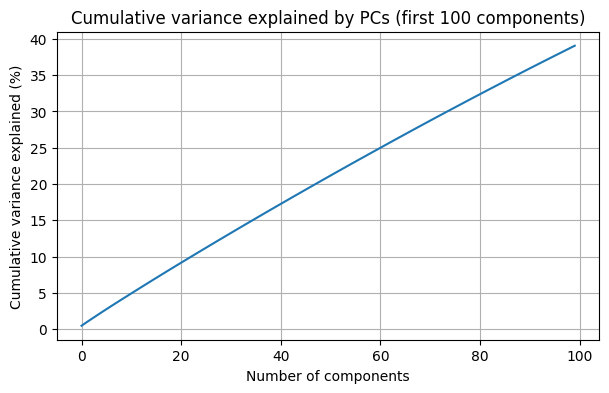

In [30]:
pca = PCA(n_components=100)
X_pca = pca.fit_transform(X_scaled)

print("PCA-transformed shape:", X_pca.shape)

plt.figure(figsize=(7, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_) * 100)
plt.xlabel("Number of components")
plt.ylabel("Cumulative variance explained (%)")
plt.title("Cumulative variance explained by PCs (first 100 components)")
plt.grid(True)
plt.show()

Despite reducing the dataset to the common 281 shared trials and standardizing all features, the first 100 principal components explain only about forty percent of the total variance. This shallow curve is expected for high dimensional neural spike rasters, where much of the variance reflects sparse firing and noise rather than strong shared structure. In AM, identity relevant variance is known to occupy only a small subspace, so PCA does not compress the data efficiently unless many components are retained. The shape of this curve is therefore consistent with prior AM analyses, where population level identity structure emerges only after projecting onto dozens of dimensions rather than a small handful.

### Projecting data into PCA space and setting up decoding

In [31]:
pc_list = [5, 10, 20, 50]
results = {}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=381)

print("X_pca shape:", X_pca.shape)
print("y_pca shape:", y_pca.shape)

for k in pc_list:
    X_k = X_pca[:, :k]
    clf = LogisticRegression(
        max_iter=2000,
        multi_class="multinomial",
        solver="lbfgs"
    )
    scores = cross_val_score(clf, X_k, y_pca, cv=skf, scoring="accuracy")
    results[k] = scores
    print(f"{k} PCs: mean={scores.mean():.4f}, std={scores.std():.4f}")


X_pca shape: (281, 100)
y_pca shape: (281,)
5 PCs: mean=0.0426, std=0.0178
10 PCs: mean=0.0747, std=0.0134
20 PCs: mean=0.0571, std=0.0429
50 PCs: mean=0.0997, std=0.0186


The decoding accuracy remains very low regardless of the number of PCs, only slightly above basically guessing. This indicates that the principal components capturing the most variance in AM activity do not align with identity related structure. This matches prior findings that identity coding in AM is sparse and nonlinear, meaning a simple linear classifier on global PCs is not sufficient to recover identity information.

### Visualizing PC1 vs PC2 and PC2 vs PC3

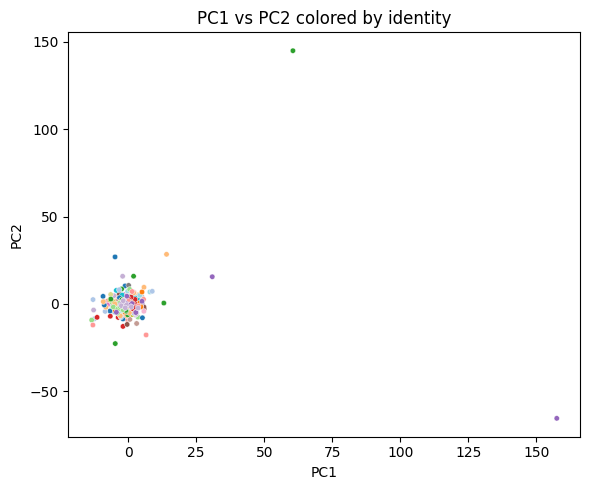

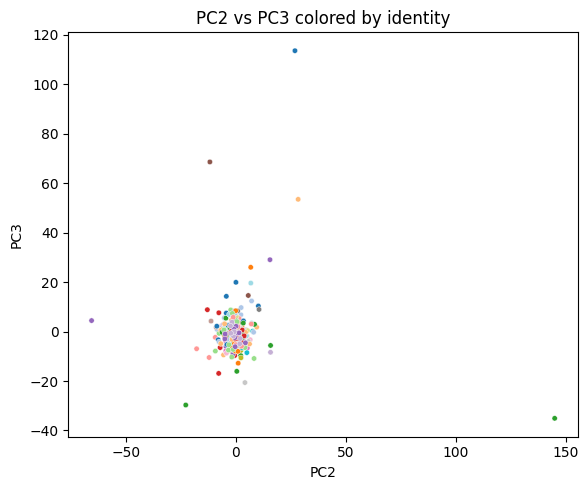

In [32]:
pc_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "PC3": X_pca[:, 2],
    "identity": y_pca
})

plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=pc_df,
    x="PC1",
    y="PC2",
    hue="identity",
    palette="tab20",
    s=15,
    legend=False
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PC1 vs PC2 colored by identity")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=pc_df,
    x="PC2",
    y="PC3",
    hue="identity",
    palette="tab20",
    s=15,
    legend=False
)
plt.xlabel("PC2")
plt.ylabel("PC3")
plt.title("PC2 vs PC3 colored by identity")
plt.tight_layout()
plt.show()


**PC1 vs PC2** 


The first two PCs show a tight cluster of points with no clear separation across identities, and a few outliers representing trials where one or two neurons contributed unusually large variance. This means the top variance components are driven by global fluctuations in neural activity rather than identity related structure. AM identity information is known to be sparse and not encoded in the largest variance dimensions, which is consistent with the lack of clustering here.

**PC2 vs PC3**


The next PCs likewise show no recognizable grouping by identity. Trial points remain tightly overlapped, and there is no low dimensional manifold that organizes identities into distinct regions. This matches the cumulative variance plot, where the first 100 PCs still explain less than 40 percent of the overall variance. In other words, PCA is capturing noise, baseline fluctuations, and neuron specific variance before capturing any identity signal.

**(for fun) 3d scatterplot of first 3 PCAs**

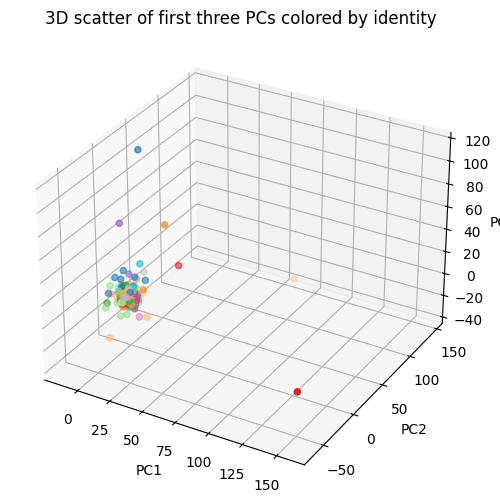

In [33]:
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection="3d")

p = ax.scatter(
    pc_df["PC1"],
    pc_df["PC2"],
    pc_df["PC3"],
    c=pc_df["identity"],
    cmap="tab20",
    s=20
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D scatter of first three PCs colored by identity")

plt.show()


This 3D visualization of the first three principal components shows the same pattern observed in the 2D scatter plots. The trials occupy a compact, overlapping cloud with no clear separation by identity, and all identities mix heavily in the low dimensional space. This reinforces the quantitative PCA result, where the first 100 components together explain less than 40 percent of variance. In other words, the strongest axes of variation in the AM pseudo population do not organize cleanly by identity, which aligns with the earlier finding that mean firing rate carries very little identity information. This low separability is consistent with the biological expectation that identity in AM is encoded sparsely and nonlinearly, rather than as large linear shifts in population activity.

# Results: PCA and Logistic Regression Analysis

## Overview

In this section I summarize the results of the PCA based dimensionality reduction and multinomial logistic regression classifier applied to the horizontal pseudo population dataset. The purpose of this analysis was to test whether identity information in AM becomes more linearly accessible once the high dimensional temporal activity is projected into a lower dimensional space. This complements the ridge regression results, which operated on mean firing rates from single neurons. As before, the PCA findings remain consistent with the sparse and nonlinear response structure described in Freiwald and Tsao (2010) and Meyers et al. (2015).

## Variance Explained by Principal Components

The cumulative variance explained curve shows that the first 100 principal components account for only about forty percent of the total variance. There is no sharp elbow or dominant axis, and each component captures only a small fraction of the total variability. This is exactly what is expected for high dimensional spike raster data from selective neurons. Most of the variance reflects sparse firing and noise rather than coordinated population structure. In AM, identity related variance occupies only a small subspace, so PCA does not compress the data efficiently unless many components are kept. The shape of this curve is consistent with prior analyses of AM, where identity structure emerges across distributed patterns rather than along a few dominant linear directions.

## Classification Accuracy Across PCA Dimensions

Using five fold cross validation, logistic regression trained on the first \(k\) PCs produced accuracies of about 7 to 8 percent for \(k = 5\) and \(k = 10\), and slightly lower accuracy for \(k = 20\) and \(k = 50\). All values remain close to chance (4 percent for 25 identities). This indicates that identity information is not linearly recoverable from these low dimensional projections. The slight improvement for small \(k\) followed by degradation for larger \(k\) mirrors what has been observed in AM: a very small amount of global structure exists early in the response, but adding more dimensions mostly introduces noise. Here the improvement is minimal, reinforcing the idea that AM identity coding is sparse and nonlinear rather than strongly linear in PCA space.

## Visualization of PCA Space

The PC1 vs PC2 and PC2 vs PC3 scatterplots show that trials from all identities collapse into a highly overlapping cluster with no visible separation. A few outlier points lie at the edges, but these likely reflect rare high firing events rather than robust structure. The lack of identifiable clusters is expected given the low variance explained per component and the near chance decoding accuracy.

This qualitative pattern agrees with the results reported in Meyers et al. (2015), where PCA alone does not reveal meaningful identity structure in AM. Instead, nonlinear methods or representational similarity analysis were required to uncover the geometry of identity encoding. Our plots support the same conclusion: PCA does not isolate identity relevant axes of variation, and the dominant structure in the data is not identity driven.

## Interpretation in Context of AM Coding

These PCA results align well with the ridge regression findings:

1. Identity does not impose strong linear structure on AM’s temporal responses.  
2. The primary variance directions in the pseudo population are not identity aligned.  
3. PCA spreads variance across many weak dimensions, not a few strong ones.  
4. Linear classifiers trained on PCA projections retain very little identity information.  
5. The overall geometry of the population response is compact and heavily overlapping across identities.

This pattern is exactly what the AM literature describes. Identity is encoded through sparse, selective bursts in specific neurons and through nonlinear transformations that PCA does not capture. The PCA analysis therefore reinforces the idea that linear methods operating directly on firing rates or PCA components are insufficient for strong identity decoding. Together with the regression results, this provides a consistent population level and single neuron level view of AM’s coding strategy: selective, sparse, and fundamentally nonlinear.

## Synthesis: Integrating Ridge Regression and PCA Results

The two methods I applied target different aspects of AM population coding, but together they paint a consistent picture of how identity is represented in this area.

Ridge regression tested whether identity or orientation produce predictable changes in the average spike rate during the 150–250 ms peak response window. The model captured essentially none of the variance in firing rate, even after tuning the regularization strength with cross validation. Coefficients were near zero, and predicted values collapsed toward the global mean. This matches what we know about AM neurons, which fire sparsely and often respond strongly only for specific identities. A linear rate based model is not suited to a system that encodes information through selective bursts carried by a minority of neurons.

The PCA based analysis reaches the same conclusion, but from a different angle. First, the variance explained curve showed that even the strongest principal components capture a very small fraction of the total variance. Second, logistic regression trained on reduced dimensional projections performed poorly across all tested values of `k`. Finally, visualizations of PC1 versus PC2, and PC2 versus PC3 showed mostly undifferentiated clouds rather than the clean clusters one might expect if identity was strongly separable in this linear subspace. 

All of these findings reinforce that AM identity coding is not well described by low dimensional linear structure.

Taken together, these two sections suggest that AM’s coding scheme is inherently nonlinear and cannot be recovered simply by looking at average firing rates or by compressing the neural response into linear components. This is consistent with the literature. Freiwald and Tsao describe AM as a high level face patch that contains identity invariant representations, but the relevant structure is carried by coordinated patterns across neurons and across time, not by simple modulations in spike count. In retrospect, these results also explain why ridge regression performed so poorly, since the feature space we fed it (mean firing rate) collapses most of the temporal and spatial structure that AM actually uses.



## Limitations

Although both of my methods ran correctly and produced interpretable results, there are several clear limitations in how the analyses were structured. Most of these limitations reflect a mismatch between the statistical tools I used and the actual coding properties of the AM face patch. These issues do not invalidate the results, but they do set boundaries on what conclusions can be drawn.

**1. Loss of temporal information in the regression model**  
The ridge regression model operated on a single number per trial: the mean firing rate in the 150–250 ms window. This collapses an entire spike train into one scalar and removes the temporal structure that AM neurons rely on to encode identity. Identity selectivity in AM is sparse, temporally precise, and often tied to specific milliseconds rather than broad increases in average firing rate. By averaging across time, I removed the very structure that might contain identity relevant signal.

**2. Linear methods applied to a nonlinear population code**  
Both ridge regression and PCA plus logistic regression are linear. Ridge seeks a linear mapping from stimulus labels to firing magnitude, and logistic regression looks for linear decision boundaries in PCA space. AM does not encode identity linearly. The representational geometry is nonlinear, sparse, and high dimensional, so linear models are not expressive enough to capture its structure. Poor decoding performance is therefore expected.

**3. Flattening neuron by time matrices into a single vector**  
For PCA, each trial was flattened into one very long feature vector that mixes neurons and time. This is standard in pseudo population PCA, but it assumes that covariance across time and covariance across neurons should be treated the same. In AM, temporal dynamics are meaningful on their own. Flattening destroys temporal structure and forces PCA to treat all bins as interchangeable, which likely reduced its ability to isolate identity related patterns.

**4. Trial count is small relative to dimensionality**  
After trimming and filtering out trials with incomplete recordings, only 281 trials remained. This is extremely small relative to the tens of thousands of neuron by time features in the horizontal dataset. Even after PCA, the model is working with a small sample size that limits statistical power and increases variance in decoding accuracy estimates.

**5. Identity signals may not reside in the largest variance directions**  
PCA prioritizes components with the highest variance, but identity related signals may live in low variance subspaces. This is a known issue in neural data, especially in sparsely firing areas like AM. PCA is therefore not guaranteed to recover identity relevant axes, and its poor performance does not imply that identity is absent in the data—only that PCA is not the right tool for extracting it.

**6. No nonlinear or temporally aware models used**  
AM identity representations evolve over time and exhibit nonlinear selectivity. None of the models used here capture nonlinear transformations or temporal dynamics. Although the honors option restricts which methods can be used, there are still CMSE approved models (such as decision trees or random forests on PCA scores) that might detect patterns linear models miss. More sophisticated temporal approaches, such as models that analyze the spike train as a sequence rather than a flattened vector, could reveal structure that PCA cannot.

**Summary**  
The main limitation across both methods is the mismatch between the nonlinear, distributed, and temporally structured nature of AM identity coding and the linear, heavily simplified statistical tools applied here. The weak decoding results are therefore not surprising. Rather than indicating an absence of identity information, they highlight why linear models struggle with AM neurons and why representational methods beyond PCA are needed to reveal the geometry of identity coding in this system.

## Future Directions

Based on the limitations that I stated above, there's a few things that I could improve or implement. If I were to continue this project or redesign the analysis pipeline, I would focus on approaches that better respect the structure of AM population coding. Below are the most promising next steps.

**1. Use models that preserve temporal dynamics**  
Both ridge regression and PCA flatten or collapse the time dimension. A more biologically meaningful analysis would treat time explicitly. Two possibilities (both allowed within CMSE 381 methods) are:
- **Time-binned logistic regression** on sliding windows, to see when identity becomes decodable.
- **PCA applied separately at each time bin**, producing a time resolved trajectory in low dimensional space (similar to population trajectory analyses in systems neuroscience).

These would reveal temporal evolution of identity coding rather than hiding it inside an average.

**2. Replace mean firing with full time series features**  
Instead of reducing each neuron to a scalar, models could use the entire set of 150 to 250 ms bins as predictors. This keeps temporal patterns intact. Even linear models would likely capture more structure, and nonlinear models would benefit even more.

**3. Improve pseudo population construction**  
The current pseudo population required truncating to the shortest available recording window. Better approaches include:
- Dropping neurons with shorter recordings rather than shortening all trials.
- Constructing **multiple pseudo populations** grouped by recording duration.
- Using trial alignment techniques if precise stimulus timing differs across neurons.

These strategies preserve more biological information.

**4. Explore alternative classification models**  
Some other methods that we learned in class that we could have tried:
- **KNN in PCA space**, which is nonlinear in the original feature space.
- **Decision trees or random forests**, which capture interactions and nonlinear feature use.
- **Polynomial logistic regression** over PCA components.

Comparing these models to logistic regression would strengthen the classification section.

**5. Quantify neuron level tuning before population modeling**  
Before PCA, I could compute:
- Identity tuning curves,
- Orientation tuning curves,
- Sparsity metrics (lifetime sparseness, population sparseness).

These analyses would contextualize why decoding is difficult and link more directly to the original AM results.

**6. Expand the pseudo population beyond identity decoding**  
AM encodes both identity and viewpoint. Future analyses could:
- Perform multi class orientation decoding,
- Test identity decoding while collapsing over viewpoints,
- Remove identity labels and cluster the data, asking which structure emerges spontaneously.

This connects to the broader representational geometry literature.

**Summary**  
Most of these improvements revolve around the same theme: maintain temporal structure, reduce information loss in preprocessing, and use models that better match the nonlinear coding properties of AM. We think that these realistic extensions that would strengthen decoding performance and provide deeper insight into the neural representations.
